In [82]:
import pandas as pd
import numpy as np

In [83]:
df = pd.read_csv('PEA04.20231018T191000.csv')
df.head()

,STATISTIC Label,Year,Age Group,Sex,Region,UNIT,VALUE
0,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,State,Thousand,356.0
1,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,Border,Thousand,30.7
2,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,West,Thousand,32.6
3,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,Mid-West,Thousand,35.0
4,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,South-East,Thousand,32.0


In [84]:
df.shape

(6669, 7)

In [85]:
df.isna().sum()

STATISTIC Label    0
Year               0
Age Group          0
Sex                0
Region             0
UNIT               0
VALUE              0
dtype: int64

In [86]:
df.dtypes

STATISTIC Label     object
Year                 int64
Age Group           object
Sex                 object
Region              object
UNIT                object
VALUE              float64
dtype: object

In [87]:
df.describe()

,Year,VALUE
count,6669.000000,6669.000000
mean,2017.000000,75.670460
std,3.741938,281.512172
min,2011.000000,1.200000
25%,2014.000000,12.500000
50%,2017.000000,20.700000
75%,2020.000000,42.200000
max,2023.000000,5281.600000


In [88]:
df.columns

Index(['STATISTIC Label', 'Year', 'Age Group', 'Sex', 'Region', 'UNIT',
       'VALUE'],
      dtype='object')

In [89]:

# changing the columns name to make it easy to understand.
# inplace = True set the valuses parmently so that we can use the new columns names
df.rename(columns={'STATISTIC Label': 'statistic_label', 'Year': 'year', 'Age Group':'age_group', 'Sex':'sex', 'Region':'region', 'UNIT':'unit','VALUE':'value'},inplace=True)

In [90]:
df.head()

,statistic_label,year,age_group,sex,region,unit,value
0,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,State,Thousand,356.0
1,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,Border,Thousand,30.7
2,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,West,Thousand,32.6
3,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,Mid-West,Thousand,35.0
4,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,South-East,Thousand,32.0


In [91]:
#now drop tha table one that is "statistic_label" because there is no any usefull data only text is reperting throught the table  so eliminate it
df.drop({'statistic_label', 'unit'}, axis=1, inplace=True)

In [92]:
## and the valuse are in thousand to we multiply the values column in thousand
df['value'] = df['value']*1000

In [93]:
df.head()
#2011	0 - 4 years	Male	State

,year,age_group,sex,region,value
0,2011,0 - 4 years,Both sexes,State,356000.0
1,2011,0 - 4 years,Both sexes,Border,30700.0
2,2011,0 - 4 years,Both sexes,West,32600.0
3,2011,0 - 4 years,Both sexes,Mid-West,35000.0
4,2011,0 - 4 years,Both sexes,South-East,32000.0


In [94]:
filt1 = (df['age_group'] == '0 - 4 years') & (df['sex'] == 'Both sexes') & (df['region'] == 'State')

In [95]:
pop_2011 = df.loc[filt1]
pop_2011.loc[pop_2011['year']==2023, 'value']

6156    293800.0
Name: value, dtype: float64

In [96]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Population in States form 2011 - 2023 of age group 0 - 4 years')

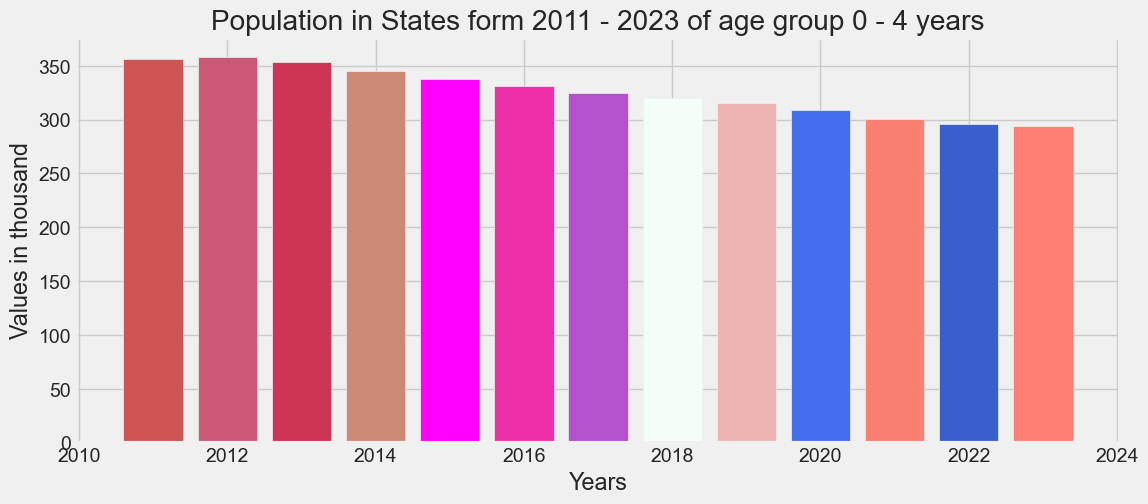

In [97]:
fig, BarGraph = plt.subplots(figsize=(12, 5))
bar_colors = ['#CD5555','#CD5777','#CD3455','#CD8977', '#FF00FF', '#EE30A7', '#B452CD', '#F5FFFA','#EEB4B4', '#436EEE', '#FA8072', '#3A5FCD', '#FF8072']
BarGraph.bar(pop_2011['year'], pop_2011['value']/1000, color = bar_colors)
plt.style.use('fivethirtyeight')
plt.xlabel('Years')
plt.ylabel('Values in thousand')
plt.title("Population in States form 2011 - 2023 of age group 0 - 4 years")


In [112]:
# we can see that there is slightly decrease in population for 2011 to 2023 which indicate that the birth rate has decresed by
#now calculate the change
pop_dec_per_state = (pop_2011.loc[pop_2011['year']==2023, 'value'] - pop_2011.loc[pop_2011['year']==2011, 'value'])
pop_dec_per_state = (pop_dec_per_state/(pop_2011.loc[pop_2011['year']==2011, 'value']))*100

In [113]:
pop_dec_per_state

0      NaN
6156   NaN
Name: value, dtype: float64